# Survey Overview (Sharing-Eligible Responses)

This notebook loads `survey.csv`, filters to students who agreed their responses can be shared beyond class context, and explores trends with a few visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("survey.csv")
print(f"Loaded {len(df)} responses with {df.shape[1]} columns.")

Loaded 98 responses with 19 columns.


In [2]:
# Locate consent column and build consent flags
consent_col = [c for c in df.columns if c.startswith("This feedback may be valuable")][0]
consent = df[consent_col].fillna("")

consent_opts = {
    "agg_summary": "I consent to my responses being included in anonymous, aggregated summaries.",
    "anon_quotes": "I consent to anonymous direct quotes from my responses being used.",
    "named_use": "I consent to my name being attached to my responses if useful for broader discussion.",
    "do_not_use": "Please do not use my responses outside this course context.",
    "follow_up": "I’m open to a follow-up conversation; please contact me."
}

for k, phrase in consent_opts.items():
    df[k] = consent.str.contains(phrase, regex=False)

# "Agreed to share beyond class" definition used here:
# opted into at least one broader sharing option, and did not opt into "do not use outside course context"
df["share_beyond_class"] = (
    (df["agg_summary"] | df["anon_quotes"] | df["named_use"]) & ~df["do_not_use"]
)

df_share = df[df["share_beyond_class"]].copy()

print(f"Responses agreeing to share beyond class: {len(df_share)} / {len(df)}")
print("Consent option counts (all responses):")
print(df[["agg_summary", "anon_quotes", "named_use", "do_not_use", "follow_up"]].sum().sort_values(ascending=False))

Responses agreeing to share beyond class: 52 / 98
Consent option counts (all responses):
agg_summary    87
anon_quotes    70
do_not_use     45
follow_up      27
named_use      23
dtype: int64


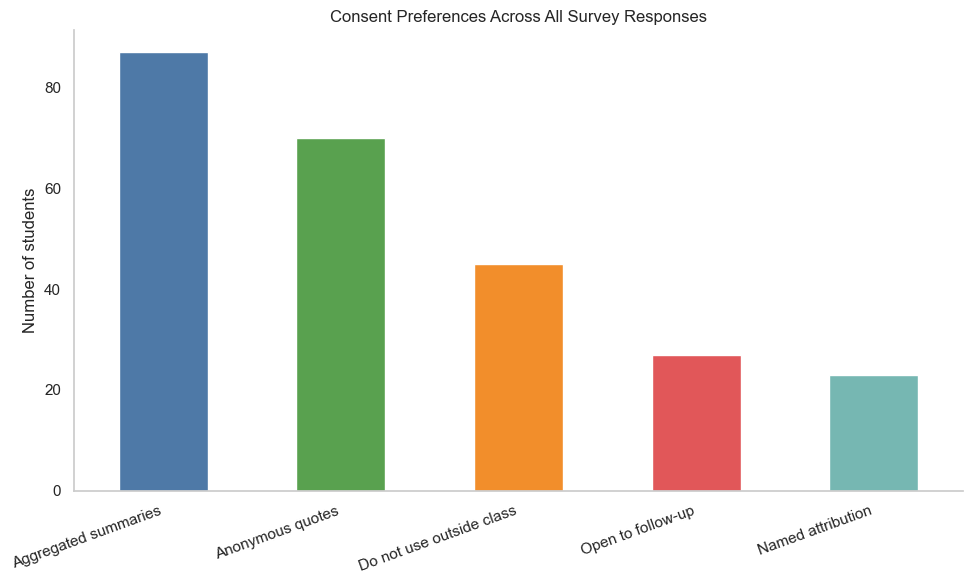

In [3]:
# Plot 1: Consent option uptake across all respondents
consent_counts = df[["agg_summary", "anon_quotes", "named_use", "do_not_use", "follow_up"]].sum().sort_values(ascending=False)
labels = {
    "agg_summary": "Aggregated summaries",
    "anon_quotes": "Anonymous quotes",
    "named_use": "Named attribution",
    "do_not_use": "Do not use outside class",
    "follow_up": "Open to follow-up"
}

ax = consent_counts.rename(index=labels).plot(kind="bar", color=["#4E79A7", "#59A14F", "#F28E2B", "#E15759", "#76B7B2"])
ax.set_title("Consent Preferences Across All Survey Responses")
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Number of students")
ax.set_xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

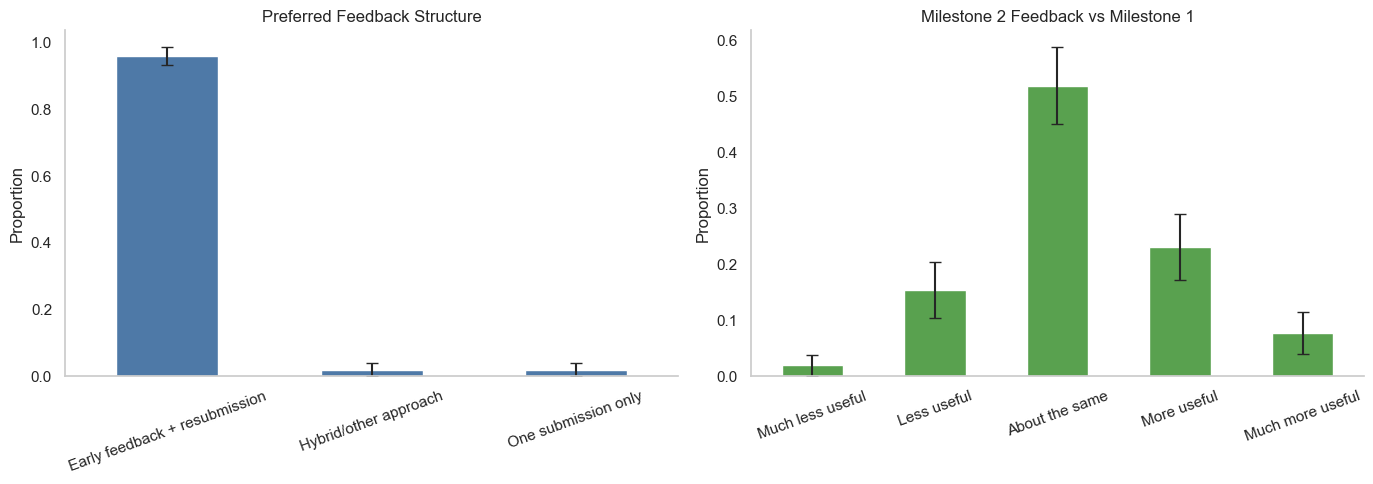

In [4]:
# Plot 2: Distribution of milestone preference and perceived usefulness (sharing-eligible only)
pref_col = "Which feedback structure do you prefer overall for milestones?"
useful_col = "Compared with Milestone 1 feedback, Milestone 2 feedback was:"

import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: preferred structure with SE error bars
left_counts = df_share[pref_col].value_counts()
n_left = left_counts.sum()
left_p = left_counts / n_left
left_se = np.sqrt(left_p * (1 - left_p) / n_left)

left_p.plot(kind="bar", ax=axes[0], color="#4E79A7", yerr=left_se, capsize=4)
axes[0].set_title("Preferred Feedback Structure")
axes[0].set_xlabel("")
axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(False)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Right: usefulness with SE error bars (ordered)
usefulness_order = ["Much less useful", "Less useful", "About the same", "More useful", "Much more useful"]
right_counts = (
    df_share[useful_col]
    .value_counts()
    .reindex(usefulness_order)
    .fillna(0)
)
n_right = right_counts.sum()
right_p = right_counts / n_right
right_se = np.sqrt(right_p * (1 - right_p) / n_right)

right_p.plot(kind="bar", ax=axes[1], color="#59A14F", yerr=right_se, capsize=4)
axes[1].set_title("Milestone 2 Feedback vs Milestone 1")
axes[1].set_xlabel("")
axes[1].set_ylabel("Proportion")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(False)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


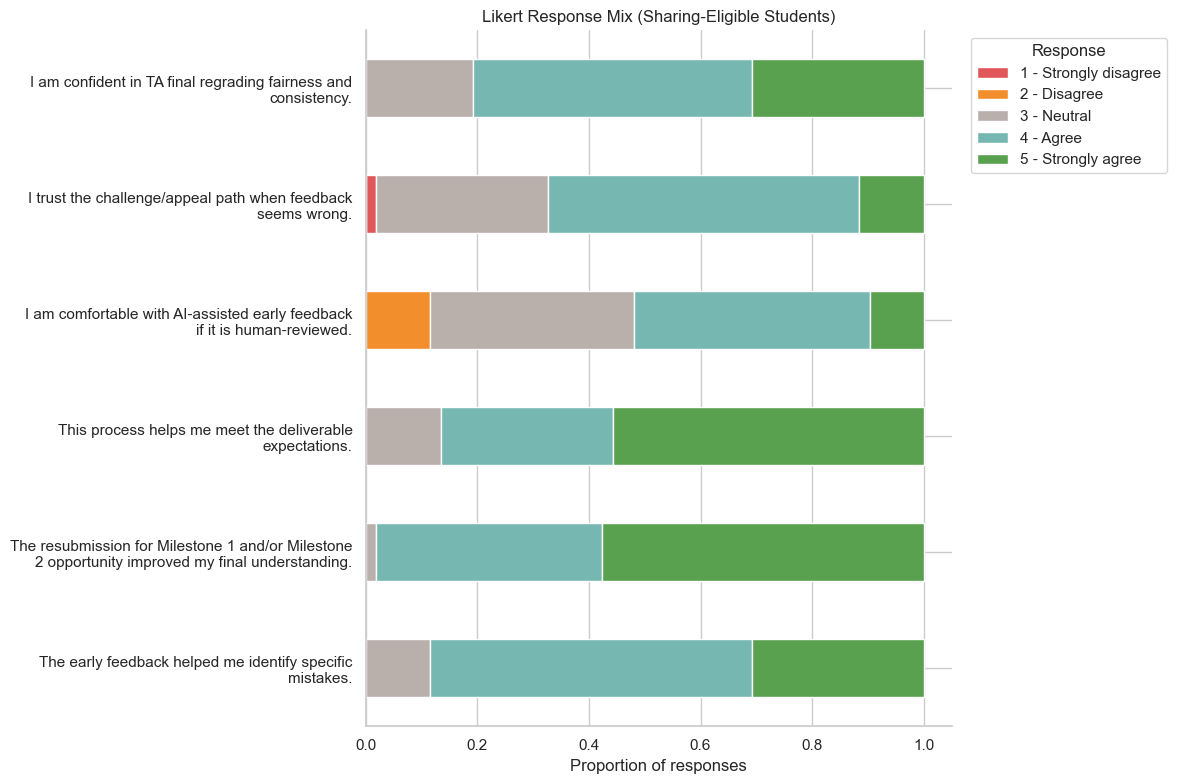

In [5]:
# Plot 3: Likert distributions for key process-confidence statements (sharing-eligible only)
from textwrap import fill

likert_cols = [
    "The early feedback helped me identify specific mistakes.",
    "The resubmission for Milestone 1 and/or Milestone 2 opportunity improved my final understanding.",
    "This process helps me meet the deliverable expectations.",
    "I am comfortable with AI-assisted early feedback if it is human-reviewed.",
    "I trust the challenge/appeal path when feedback seems wrong.",
    "I am confident in TA final regrading fairness and consistency."
]

likert_order = [
    "1 - Strongly disagree",
    "2 - Disagree",
    "3 - Neutral",
    "4 - Agree",
    "5 - Strongly agree"
]

dist = []
for col in likert_cols:
    row = df_share[col].value_counts(normalize=True).reindex(likert_order).fillna(0)
    dist.append(row)

dist_df = pd.DataFrame(dist, index=likert_cols)

# Wrap each question label to ~45 chars per line
wrapped_index = [fill(q, width=50) for q in dist_df.index]
dist_df_wrapped = dist_df.copy()
dist_df_wrapped.index = wrapped_index

colors = ["#E15759", "#F28E2B", "#BAB0AB", "#76B7B2", "#59A14F"]
ax = dist_df_wrapped.plot(kind="barh", stacked=True, color=colors, figsize=(12, 8))
ax.set_title("Likert Response Mix (Sharing-Eligible Students)")
ax.set_xlabel("Proportion of responses")
ax.set_ylabel("")
ax.legend(title="Response", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

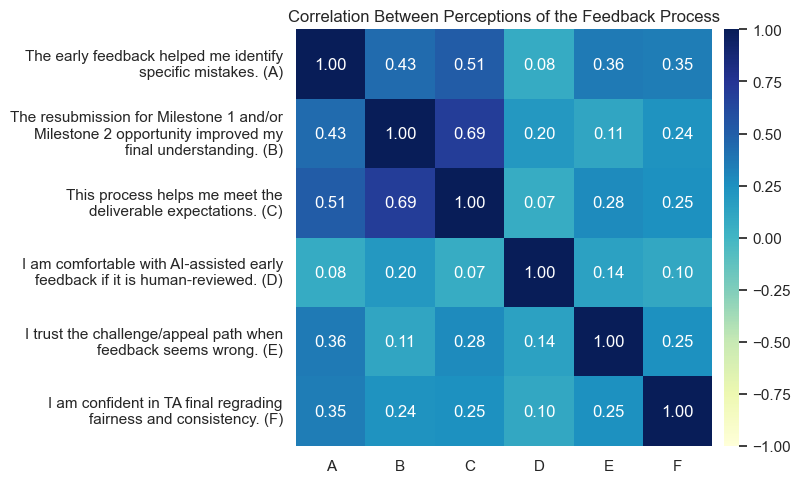

A) The early feedback helped me identify specific mistakes.
B) The resubmission for Milestone 1 and/or Milestone 2 opportunity improved my final understanding.
C) This process helps me meet the deliverable expectations.
D) I am comfortable with AI-assisted early feedback if it is human-reviewed.
E) I trust the challenge/appeal path when feedback seems wrong.
F) I am confident in TA final regrading fairness and consistency.


In [6]:
# Plot 4: Correlation heatmap among Likert items (sharing-eligible only)
# Convert Likert labels to numeric scale 1..5 using the leading number

from textwrap import fill
from mpl_toolkits.axes_grid1 import make_axes_locatable
import string

# Convert Likert labels to numeric scale 1..5 using leading number
likert_num = df_share[likert_cols].apply(
    lambda s: pd.to_numeric(s.str.extract(r"^(\d)")[0], errors="coerce")
)
corr = likert_num.corr()

# Build A, B, C... labels
letters = list(string.ascii_uppercase[:len(likert_cols)])
wrapped_y = [f"{fill(q, width=40)} ({letters[i]})" for i, q in enumerate(likert_cols)]
x_short = letters

# Bigger figure so wrapped y-labels fit
fig, ax = plt.subplots(figsize=(7, 5))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3.5%", pad=0.12)  # same height as heatmap

sns.heatmap(
    corr,
    annot=True,
    cmap="YlGnBu",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True,
    xticklabels=x_short,
    yticklabels=wrapped_y,
    ax=ax,
    cbar_ax=cax
)

ax.set_title("Correlation Between Perceptions of the Feedback Process")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

# Optional key for A/B/C...
for i, q in enumerate(likert_cols):
    print(f"{letters[i]}) {q}")


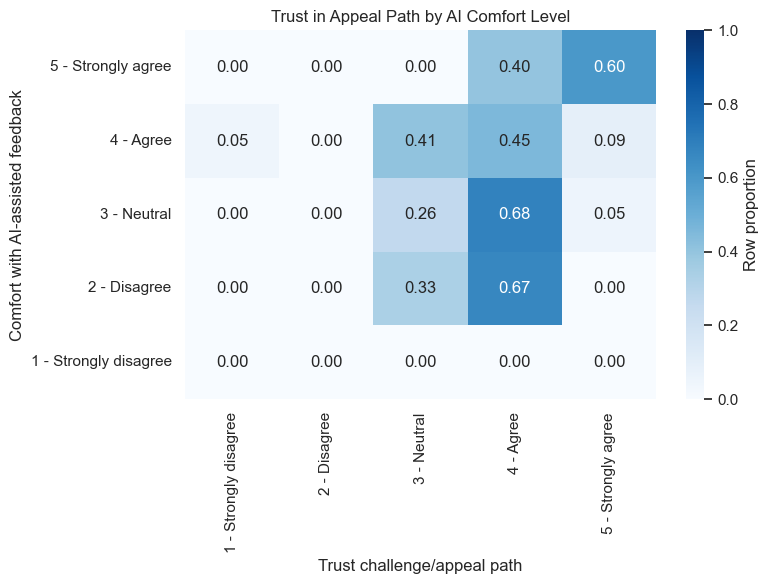

In [7]:
# Plot 5: Relationship between AI comfort and trust in challenge/appeal path
ai_col = "I am comfortable with AI-assisted early feedback if it is human-reviewed."
trust_col = "I trust the challenge/appeal path when feedback seems wrong."

y_order = likert_order[::-1]  # Strongly agree -> ... -> Strongly disagree

ct = pd.crosstab(df_share[ai_col], df_share[trust_col], normalize="index")
ct = ct.reindex(index=y_order, columns=likert_order, fill_value=0).fillna(0)

plt.figure(figsize=(8, 6))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", cbar_kws={"label": "Row proportion"}, vmin=0, vmax=1)
plt.title("Trust in Appeal Path by AI Comfort Level")
plt.xlabel("Trust challenge/appeal path")
plt.ylabel("Comfort with AI-assisted feedback")
# plt.grid(False)
plt.tight_layout()

plt.show()

In [8]:
# Quick numeric summary for interpretation
print("Sharing-eligible sample size:", len(df_share))
print("Top preferred structure:")
print(df_share[pref_col].value_counts().head(3))

print("Average Likert scores (1-5):")
mean_scores = likert_num.mean().sort_values(ascending=False)
for k, v in mean_scores.items():
    print(f"- {k}: {v:.2f}")

Sharing-eligible sample size: 52
Top preferred structure:
Which feedback structure do you prefer overall for milestones?
Early feedback + resubmission    50
Hybrid/other approach             1
One submission only               1
Name: count, dtype: int64
Average Likert scores (1-5):
- The resubmission for Milestone 1 and/or Milestone 2 opportunity improved my final understanding.: 4.56
- This process helps me meet the deliverable expectations.: 4.42
- The early feedback helped me identify specific mistakes.: 4.19
- I am confident in TA final regrading fairness and consistency.: 4.12
- I trust the challenge/appeal path when feedback seems wrong.: 3.75
- I am comfortable with AI-assisted early feedback if it is human-reviewed.: 3.50


In [25]:
# If needed:
# !pip install -q sentence-transformers scikit-learn plotly

import numpy as np
import pandas as pd
import plotly.express as px
from textwrap import fill
from html import escape
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

import warnings
import re
warnings.resetwarnings()
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module=r"sklearn\.utils\.extmath"
)


# ---------- 1) Load + consent filter ----------
df = pd.read_csv("survey.csv")

consent_col = [c for c in df.columns if c.startswith("This feedback may be valuable")][0]
consent = df[consent_col].fillna("")

opts = {
    "agg": "I consent to my responses being included in anonymous, aggregated summaries.",
    "quotes": "I consent to anonymous direct quotes from my responses being used.",
    "named": "I consent to my name being attached to my responses if useful for broader discussion.",
    "no": "Please do not use my responses outside this course context."
}

df["share_beyond_class"] = (
    (consent.str.contains(opts["agg"], regex=False) |
     consent.str.contains(opts["quotes"], regex=False) |
     consent.str.contains(opts["named"], regex=False))
    & ~consent.str.contains(opts["no"], regex=False)
)

df_share = df[df["share_beyond_class"]].copy()
print(f"Share-beyond-class responses: {len(df_share)} / {len(df)}")


# ---------- 2) Open-ended columns ----------
open_ended_cols = [
    "How did the submit + quick detailed feedback + resubmission cycle affect your learning process?",
    "In what assignment scenarios would you NOT want this model (early feedback + resubmission)?",
    "Biggest advantage for you of bringing GenAI into early feedback:",
    "Biggest disadvantage for you of bringing GenAI into early feedback:",
    # "One concrete change you recommend for the next milestone feedback process:",
    "What else would you like to share with the instructor and TAs on this topic?"
]

sentence_model = SentenceTransformer("all-MiniLM-L6-v2")


def analyze_open_ended(question_col, min_chars=12):
    s = df_share[question_col].dropna().astype(str).str.strip()
    s = s[s.str.len() >= min_chars]
    docs = s.tolist()
    docs = pd.Series(docs).dropna().astype(str).str.strip()
    docs = docs[docs.str.len() >= 5].drop_duplicates().tolist()


    print("\n" + "=" * 90)
    print(question_col)
    print(f"Usable responses: {len(docs)}")

    if len(docs) < 8:
        print("Too few responses for stable clustering/visualization. Skipping.")
        return

    # Embeddings
    emb = sentence_model.encode(
        docs,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True
    ).astype(np.float32)
    emb = np.ascontiguousarray(emb, dtype=np.float32)
    emb = np.nan_to_num(emb, nan=0.0, posinf=1.0, neginf=-1.0)
    perplexity = max(2, min(8, len(emb) - 1))

    # Agglomerative clusters
    n_clusters = min(6, max(2, int(np.sqrt(len(docs) / 2))))
    labels = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward").fit_predict(emb)

    # t-SNE
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=perplexity,
        init="random",
        learning_rate="auto",
        metric="euclidean",   # more stable; on normalized vectors it's fine
        method="exact",       # stable for small N like ~50
        max_iter=2000
    )
    xy = tsne.fit_transform(emb)

    plot_df = pd.DataFrame({
        "x": xy[:, 0],
        "y": xy[:, 1],
        "cluster": labels.astype(str),
        "doc_num": [f"Resp {i+1}" for i in range(len(docs))],
        "document": docs,
        "wrapped_doc": [fill(d, width=60).replace("\n", "<br>") for d in docs]
    }).sort_values("cluster")

    fig = px.scatter(
        plot_df,
        x="x",
        y="y",
        color="cluster",
        custom_data=["doc_num", "wrapped_doc", "cluster"],
        # title=f"t-SNE + Agglomerative: {question_col}",
        title=f"<b>{question_col}</b>",
        labels={"cluster": "Cluster"},
        category_orders={"cluster": [str(i) for i in range(n_clusters)]}
    )

    fig.update_traces(
        marker=dict(size=11, line=dict(width=1, color="white")),
        hovertemplate="<b>%{customdata[0]}</b><br>"
                      "Cluster: %{customdata[2]}<br><br>"
                      "%{customdata[1]}<br>"
                      "<extra></extra>"
    )
    fig.update_layout(width=900, height=550, hoverlabel=dict(align="left"))
    fig.show()

    # Cluster size summary
    size_df = (
        pd.Series(labels, name="cluster")
        .value_counts()
        .sort_index()
        .rename_axis("cluster")
        .reset_index(name="count")
    )
    size_df["pct"] = (size_df["count"] / size_df["count"].sum() * 100).round(1)
    display(size_df)

    # Top keywords by cluster: frequency + c-TF-IDF distinctiveness
    # c-TF-IDF is computed on one concatenated document per cluster to emphasize
    # terms that are distinctive across clusters (not just common across responses).
    extra_stop = {"feedback", "milestone", "project", "resubmission", "submission", "genai"}
    count_vec = CountVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2)
    tfidf_vec = TfidfVectorizer(
        stop_words=list(set(count_vec.get_stop_words() or []).union(extra_stop)) if count_vec.get_stop_words() else "english",
        ngram_range=(1, 2),
        min_df=1,
        sublinear_tf=True,
    )

    X_count = count_vec.fit_transform(docs)
    vocab_count = np.array(count_vec.get_feature_names_out())

    cluster_df = pd.DataFrame({"text": docs, "cluster": labels})
    cluster_docs = (
        cluster_df.groupby("cluster")["text"]
        .apply(lambda s: " ".join(s))
        .sort_index()
    )

    X_cluster_tfidf = tfidf_vec.fit_transform(cluster_docs.values)
    vocab_tfidf = np.array(tfidf_vec.get_feature_names_out())
    cluster_index = list(cluster_docs.index)

    keyword_rows = []
    cluster_top_tfidf_terms = {}
    for c in range(n_clusters):
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            continue

        # Frequency terms inside cluster
        count_scores = np.asarray(X_count[idx].sum(axis=0)).ravel()
        count_top_idx = count_scores.argsort()[::-1][:8]
        top_count_terms = [vocab_count[i] for i in count_top_idx if count_scores[i] > 0][:6]

        # c-TF-IDF terms for this cluster
        row_i = cluster_index.index(c)
        tfidf_scores = np.asarray(X_cluster_tfidf[row_i].toarray()).ravel()
        tfidf_top_idx = tfidf_scores.argsort()[::-1][:8]
        top_tfidf_terms = [vocab_tfidf[i] for i in tfidf_top_idx if tfidf_scores[i] > 0][:6]
        cluster_top_tfidf_terms[c] = top_tfidf_terms

        keyword_rows.append({
            "cluster": c,
            "size": len(idx),
            "top_terms_count": ", ".join(top_count_terms),
            "top_terms_tfidf": ", ".join(top_tfidf_terms),
        })

    display(pd.DataFrame(keyword_rows).sort_values("cluster"))

    # Representative responses (closest to each cluster mean embedding)
    rep_rows = []
    for c in range(n_clusters):
        idx = np.where(labels == c)[0]
        if len(idx) == 0:
            continue

        # Compute a pseudo-centroid for this cluster and rank by cosine similarity.
        cluster_emb = emb[idx]
        centroid = cluster_emb.mean(axis=0, keepdims=True)
        sims = cosine_similarity(cluster_emb, centroid).ravel()
        top_local = np.argsort(sims)[::-1][:3]  # top 3 per cluster

        for rank, local_i in enumerate(top_local, start=1):
            global_i = idx[local_i]
            rep_rows.append({
                "cluster": c,
                "rank_in_cluster": rank,
                "response": docs[global_i]
            })

    rep_df = pd.DataFrame(rep_rows).sort_values(["cluster", "rank_in_cluster"]).copy()
    # rep_df["top_terms_tfidf"] = rep_df["cluster"].map(lambda c: ", ".join(cluster_top_tfidf_terms.get(c, [])))

    def bold_terms_in_text(text, terms):
        safe = escape(str(text))
        # Match longer phrases first to avoid partial overlaps.
        ordered_terms = sorted({t for t in terms if t}, key=len, reverse=True)
        for term in ordered_terms:
            safe_term = escape(term)
            pattern = re.compile(rf"(?i)(?<!\w)({re.escape(safe_term)})(?!\w)")
            safe = pattern.sub(r"<b>\1</b>", safe)
        return safe

    rep_df["response"] = rep_df.apply(
        lambda r: bold_terms_in_text(r["response"], cluster_top_tfidf_terms.get(r["cluster"], [])),
        axis=1,
    )

    # Color rows by cluster for quicker scanning.
    palette = ["#E8F1FB", "#EAF7EA", "#FFF4E5", "#FDEBEC", "#EEF2FF", "#F2F2F2"]
    cluster_to_color = {c: palette[int(c) % len(palette)] for c in sorted(rep_df["cluster"].unique())}

    def color_row(row):
        color = cluster_to_color.get(row["cluster"], "#FFFFFF")
        return [f"background-color: {color}"] * len(row)

    display(
        rep_df.style
        .apply(color_row, axis=1)
        .format({"response": lambda x: x}, escape=None)
        .set_properties(
            subset=["response"],
            **{"white-space": "normal", "text-align": "left", "max-width": "900px"}
        )
    )


# ---------- 3) Run all open-ended questions ----------
for col in open_ended_cols:
    analyze_open_ended(col)


Share-beyond-class responses: 52 / 98

How did the submit + quick detailed feedback + resubmission cycle affect your learning process?
Usable responses: 52


,cluster,count,pct
0,0,8,15.4
1,1,6,11.5
2,2,10,19.2
3,3,11,21.2
4,4,17,32.7


,cluster,size,top_terms_count,top_terms_tfidf
0,0,8,"feedback, assignment, work, mistakes, allowed,...","multiple, assignment, come, members, mistakes ..."
1,1,6,"feedback, wrong, learning, learn, grade, just","change allow, second change, just seeing, help..."
2,2,10,"feedback, milestone, understand, helped, think...","future, milestones, solid, future milestones, ..."
3,3,11,"helped, work, understand, wrong, think, just","needed improve, focused, placing, sections, ab..."
4,4,17,"feedback, resubmission, learning, able, submit...","submit quick, detailed cycle, database, submit..."


,cluster,rank_in_cluster,response
0,0,1,"I think I'm glad we get a chance to learn from our mistakes as sometimes I don't fully understand the assignments, however I wish the feedback wasn't so messily written. It definitely aided my learning that we are able to resubmit however I don't necessarily think we need such quick feedback and honestly could use a bit more time on these assignments."
1,0,2,"This submit, feedback, and resubmit cycle taught me so much more than handing something in once. At first, I thought my work was kind of correct, but with quick feedback, I could see precisely where I missed things like joins and constraints when you’re genuinely trying to talk about queries. Because everything was still fresh, going back and fixing things immediately was simple. Rather than losing points and continuing ahead, I was notified of my mistakes and why the correct answers made sense. Overall, it made the assignment experience feel more like I was building my own work rather than just getting a one lifetime grade out of it, and helped me to be more confident in what I was doing."
2,0,3,"I think it's great. I can recognize my mistakes and correct them again.This has been of great help to my studies. During the process of making the changes, I can remember the correct answers more deeply, and thus I can master them more firmly.It was also very helpful for me and my team members to communicate. Perhaps for the first assignment, we worked on it separately, each completing a certain portion. However, for the second submission, we might want a higher score, so we will go through the entire process of checking this assignment again for everyone."
3,1,1,"The submit, feedback, resubmission cycle helped me learn from my mistakes instead of just moving on. Getting feedback and having a chance to fix things made me actually understand where I went wrong rather than just accepting a grade. It also made me more willing to try my best on the first attempt knowing I'd have a chance to improve if I missed something."
4,1,2,"One thing that works really well for my learning (and grade) is getting something wrong and then getting feedback to rectify the mistake because I fully understand the concept and how to actually apply it. Therefore, the feedback and resubmssion definitely contributed greatly to the learning process."
5,1,3,It affected my learning in a positive way because I was able to get feedback while the assignment was still fresh in my mind. That made it easier to understand what I did wrong and why. I didn’t feel confused trying to connect old work with new lessons we were already moving on to. Being able to quickly fix and resubmit my work helped me actually learn from my mistakes instead of just seeing a grade and moving on.
6,2,1,"Given putting my full understanding of this course learnings into the milestones, getting detailed feedback allowed me to better understand what went wrong, why, and working on how to improve it with teammates. This gave us another opportunity to resubmit, to not only improve our grades, but to understand what was needed to be fix to continue on to our next milestone."
7,2,2,"I was able to clearly see what my group missed points on and ask questions about the feedback to get a solid understanding of my mistakes and how I could improve my work. Applying this feedback for the resubmission required having this solid understanding to ensure we met all requirements the second time, which really helped my learning for the concepts covered in the milestone."
8,2,3,"This cycle allowed me to understand where there were gaps in my knowledge/understanding, and was really helpful. In feedback for milestone 1, it was helpful to get feedback on potential future issues even though they didn't mean loss of points for that milestone. Early feedback also allows me to ask questions before moving on to future milestones."
9,3,1,It gave me the opportunity to learn from my mistakes and improve on my learning. It also mo


In what assignment scenarios would you NOT want this model (early feedback + resubmission)?
Usable responses: 45


...

,cluster,rank_in_cluster,response
0,0,1,"Sometimes feedback can be generalized and like a checklist, and make misunderstand more complex ideas."
1,0,2,Provides almost too much feedback that can be confusing
2,0,3,Some feedback can use complex language and it is hard to understand what the real issue is.
3,1,1,Many times AI can be wrong.
4,1,2,AI can be wrong
5,1,3,"In some cases, AI cannot be completely accurate."
6,2,1,One disadvantage of bringing GenAI into early feedback is that it can make me rely on it too much instead of fully thinking through the problem themselves.
7,2,2,"The biggest disadvantage of the GenAI feedback is that it states the error in a specific way and if you do not understand what the feedback is or what the error is, that could make fixing your assignment very difficult. Having human feedback is normally a lot simpler to understand and it can go into more detail about specific mistakes and how to rectify the issue."
8,2,3,It might make a strong over reliance on constant feedback where you start to lose a bit of confidence in your own work since you might have GenAI reflect on your work more.
9,3,1,"One possible disadvantage is that it can make students rely too much on external help instead of fully thinking through problems on their own. If used too often, it might reduce independent problem-solving skills. It can also create confusion about what counts as appropriate use, especially in courses with strict AI policies."



What else would you like to share with the instructor and TAs on this topic?
Usable responses: 18


,cluster,count,pct
0,0,9,50.0
1,1,4,22.2
2,2,5,27.8


,cluster,size,top_terms_count,top_terms_tfidf
0,0,9,"really, thank, class, learning, understand, as...","really, class, better, assignments, lot, learning"
1,1,4,thank,"thank quarter, share, time, time thank, quarte..."
2,2,5,"feedback, ai, really, feedback process, proces...","trust, transparency, ai, process, team, just"


,cluster,rank_in_cluster,response
0,0,1,"Thanks for offering resubmissions, it must be a lot of work to constantly regrade student's assignments so I really appreciate the care you put into the class and the commitment to our learning rather than the grade itself."
1,0,2,"I’d say this format made me more engaged with the assignment and helped me actually understand the material better. The quick feedback was the most valuable part, so keeping that fast turnaround is really important. It made the class feel more focused on learning instead of just grading."
2,0,3,"The assignments can be somewhat difficult to understand the requirements, more detail and better organization in the instructions and a clear final statement of what is required for submission would be greatly appreciated."
3,1,1,nothing else
4,1,2,Nothing as of now
5,1,3,"Nothing else, thank you for this quarter."
6,2,1,"I think overall the resub/feedback process is a good implementation, I'm just not sure why it only extends to milestones 1, 2, 3 but not the other ones."
7,2,2,I really appreciated how supportive and learning-focused this feedback process felt. The quick turnaround and clear explanations made it easier to stay engaged and improve without feeling discouraged.
8,2,3,"For Milestone 1, we received follow-up feedback after resubmitting, but the specific items that led to point deductions were not clearly highlighted in the first round of feedback. I understand it’s our responsibility to identify and fix issues, but it would be really helpful if the initial feedback explicitly listed the main deduction reasons (or the highest-impact mismatches) so we can address them before resubmission and avoid surprises."
